In [1]:
"""
Vassilios Kapaklis, March 2026

reciprocal_space_maps_corrected_with_linecut.py

2D reciprocal-space maps for square-ASI-like arrays with:
- charge-related scattering
- magnetic resonant x-ray scattering with selectable projection axis
- chunked lattice sums
- explicit 45° lattice rotation into the lab frame
- diagonal reciprocal indexing (u,v), appropriate for beam along [1,1]
- stadium-like island form factor applied ONLY to the charge channel
- optional masking of the first Brillouin zone
- optional circular beam-stop mask
- diagnostic plots of the charge form factor actually used
- line cut of combined intensity along u for an ROI around a chosen v value

Key correction
--------------
The stadium/island form factor is included ONLY in the charge/structural amplitude.
The magnetic amplitude does NOT include the stadium form factor.

So:
    A_charge(q) = Σ_j w_j F_j^stadium(q) exp(i q·r_j)

    A_mag(q)    = Σ_j [m_j · ehat(q)] exp(i q·r_j)

This matches the interpretation that the patterned stadium shape is a structural
basis effect, while the magnetic signal is handled through the resonant projection
model and the magnetic lattice sum.

Requirements
------------
numpy, matplotlib
scipy   (for scipy.special.j1)
"""

from dataclasses import dataclass
from typing import Callable, Optional, Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


ArrayLike = np.ndarray


# ======================================================================
# Data structures
# ======================================================================

@dataclass
class BasisSite:
    r: ArrayLike
    charge_weight: complex = 1.0 + 0.0j
    moment: Optional[ArrayLike] = None
    label: str = ""
    long_axis_angle_rad: float = 0.0

    def __post_init__(self):
        self.r = np.asarray(self.r, dtype=float)
        if self.moment is None:
            self.moment = np.zeros(2, dtype=float)
        else:
            self.moment = np.asarray(self.moment, dtype=float)


@dataclass
class DecoratedLattice2D:
    a1: ArrayLike
    a2: ArrayLike
    basis: List[BasisSite]

    def __post_init__(self):
        self.a1 = np.asarray(self.a1, dtype=float)
        self.a2 = np.asarray(self.a2, dtype=float)
        self.A = np.column_stack([self.a1, self.a2])


# ======================================================================
# Linear algebra helpers
# ======================================================================

def rotation_matrix(theta_rad: float) -> ArrayLike:
    c = np.cos(theta_rad)
    s = np.sin(theta_rad)
    return np.array([[c, -s], [s, c]], dtype=float)


def rotate_vectors(v: ArrayLike, theta_rad: float) -> ArrayLike:
    R = rotation_matrix(theta_rad)
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        return R @ v
    return v @ R.T


def reciprocal_basis_2d(a1: ArrayLike, a2: ArrayLike) -> Tuple[ArrayLike, ArrayLike]:
    """
    Reciprocal basis b1, b2 such that a_i · b_j = 2π δ_ij
    """
    A = np.column_stack([a1, a2])
    B = 2.0 * np.pi * np.linalg.inv(A).T
    return B[:, 0], B[:, 1]


def hk_to_q(h: ArrayLike, k: ArrayLike, b1: ArrayLike, b2: ArrayLike) -> Tuple[ArrayLike, ArrayLike]:
    qx = h * b1[0] + k * b2[0]
    qy = h * b1[1] + k * b2[1]
    return qx, qy


def diag_to_island_indices(u: ArrayLike, v: ArrayLike) -> Tuple[ArrayLike, ArrayLike]:
    """
    Diagonal indexing for beam along [1,1]:
        hx = (u + v)/2
        hy = (u - v)/2
    """
    hx = 0.5 * (u + v)
    hy = 0.5 * (u - v)
    return hx, hy


def qhat_from_grid(qx: ArrayLike, qy: ArrayLike, eps: float = 1e-15) -> Tuple[ArrayLike, ArrayLike]:
    qnorm = np.sqrt(qx**2 + qy**2)
    qnorm_safe = np.where(qnorm < eps, 1.0, qnorm)
    return qx / qnorm_safe, qy / qnorm_safe


def intensity_from_amplitude(amp: ArrayLike) -> ArrayLike:
    return np.abs(amp) ** 2


def log_image(I: ArrayLike, floor: float = 1e-8) -> ArrayLike:
    """
    Log image with support for NaN-masked pixels.
    """
    I = np.asarray(I, dtype=float)
    valid = np.isfinite(I)

    if not np.any(valid):
        return np.full_like(I, np.nan, dtype=float)

    Imax = np.nanmax(I)
    if Imax <= 0.0:
        out = np.full_like(I, np.log10(floor), dtype=float)
        out[~valid] = np.nan
        return out

    out = np.full_like(I, np.nan, dtype=float)
    Inorm = np.maximum(I[valid] / Imax, floor)
    out[valid] = np.log10(Inorm)
    return out


def sinc_unscaled(x: ArrayLike, eps: float = 1e-14) -> ArrayLike:
    """
    sinc(x) = sin(x)/x
    """
    out = np.ones_like(x, dtype=float)
    mask = np.abs(x) > eps
    out[mask] = np.sin(x[mask]) / x[mask]
    return out


# ======================================================================
# 2D charge form factor: stadium islands
# ======================================================================

def disk_form_factor_2d(qx: ArrayLike, qy: ArrayLike, radius: float) -> ArrayLike:
    """
    Fourier amplitude of a filled 2D disk of radius R.
    Normalized to 1 at q=0.
    """
    from scipy.special import j1

    q = np.sqrt(qx**2 + qy**2)
    u = radius * q

    out = np.ones_like(q, dtype=complex)
    mask = u > 1e-14
    out[mask] = 2.0 * j1(u[mask]) / u[mask]
    return out


def rectangle_form_factor_2d(qx: ArrayLike, qy: ArrayLike, lx: float, ly: float) -> ArrayLike:
    """
    Fourier amplitude of a centered filled rectangle of size lx × ly.
    Normalized to 1 at q=0.
    """
    return sinc_unscaled(0.5 * lx * qx) * sinc_unscaled(0.5 * ly * qy)


def rotate_q_to_local(qx: ArrayLike, qy: ArrayLike, angle_rad: float) -> Tuple[ArrayLike, ArrayLike]:
    """
    Rotate reciprocal coordinates into the local island frame.
    Local x' is along the island long axis.
    """
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    qx_local = c * qx + s * qy
    qy_local = -s * qx + c * qy
    return qx_local, qy_local


def stadium_form_factor_2d(
    qx: ArrayLike,
    qy: ArrayLike,
    total_length: float,
    width: float,
    angle_rad: float,
) -> ArrayLike:
    """
    2D projected stadium form factor amplitude.

    Geometry:
        total length L
        width W
        radius R = W/2
        straight half-length a = L/2 - R

    The stadium is represented as:
        rectangle of size (2a) × (2R)
        plus two semicircular endcaps
    """
    if width <= 0:
        raise ValueError("width must be positive")
    if total_length < width:
        raise ValueError("For a stadium, total_length must satisfy L >= W")

    R = 0.5 * width
    a = 0.5 * total_length - R

    qx_local, qy_local = rotate_q_to_local(qx, qy, angle_rad)

    area_rect = 2.0 * a * 2.0 * R
    area_caps = np.pi * R**2
    area_total = area_rect + area_caps

    if a <= 1e-14:
        return disk_form_factor_2d(qx_local, qy_local, R)

    F_rect = rectangle_form_factor_2d(qx_local, qy_local, lx=2.0 * a, ly=2.0 * R)
    F_disk = disk_form_factor_2d(qx_local, qy_local, R)

    phase_pair = 2.0 * np.cos(qx_local * a)

    numerator = area_rect * F_rect + area_caps * phase_pair * F_disk
    return numerator / area_total


def stadium_charge_form_factor(
    qx: ArrayLike,
    qy: ArrayLike,
    site: BasisSite,
    island_length: float = 0.70,
    island_width: float = 0.24,
) -> ArrayLike:
    """
    Charge form factor attached to each basis site.
    """
    return stadium_form_factor_2d(
        qx, qy,
        total_length=island_length,
        width=island_width,
        angle_rad=site.long_axis_angle_rad,
    )


# ======================================================================
# Supercell construction
# ======================================================================

def make_square_asi_typeI_supercell(
    a: float = 1.0,
    n1: int = 24,
    n2: int = 24,
    charge_weight_h: complex = 1.0 + 0j,
    charge_weight_v: complex = 1.0 + 0j,
    m0: float = 1.0,
    lattice_rotation_deg: float = 45.0,
) -> Tuple[DecoratedLattice2D, ArrayLike, ArrayLike, ArrayLike, DecoratedLattice2D]:
    """
    Build a square ASI-like lattice in the island frame, then rotate into the lab frame.

    Returns
    -------
    lattice_lab
    positions_lab
    charge_weights
    moments_lab
    lattice_island
    """
    a1_island = np.array([a, 0.0])
    a2_island = np.array([0.0, a])

    basis_island = [
        BasisSite(
            r=np.array([0.5 * a, 0.0]),
            charge_weight=charge_weight_h,
            moment=np.zeros(2),
            label="h",
            long_axis_angle_rad=0.0,
        ),
        BasisSite(
            r=np.array([0.0, 0.5 * a]),
            charge_weight=charge_weight_v,
            moment=np.zeros(2),
            label="v",
            long_axis_angle_rad=0.5 * np.pi,
        ),
    ]

    lattice_island = DecoratedLattice2D(a1=a1_island, a2=a2_island, basis=basis_island)

    theta = np.deg2rad(lattice_rotation_deg)

    a1_lab = rotate_vectors(a1_island, theta)
    a2_lab = rotate_vectors(a2_island, theta)

    basis_lab = [
        BasisSite(
            r=rotate_vectors(site.r, theta),
            charge_weight=site.charge_weight,
            moment=rotate_vectors(site.moment, theta),
            label=site.label,
            long_axis_angle_rad=site.long_axis_angle_rad + theta,
        )
        for site in basis_island
    ]

    lattice_lab = DecoratedLattice2D(a1=a1_lab, a2=a2_lab, basis=basis_lab)

    i_vals = np.arange(n1) - (n1 - 1) / 2
    j_vals = np.arange(n2) - (n2 - 1) / 2

    positions_lab = []
    charge_weights = []
    moments_lab = []

    for i in i_vals:
        for j in j_vals:
            parity = int(round(i + j)) % 2
            sign = -1.0 if parity else 1.0

            Rh0 = i * a1_island + j * a2_island + basis_island[0].r
            mh0 = np.array([sign * m0, 0.0])

            Rv0 = i * a1_island + j * a2_island + basis_island[1].r
            mv0 = np.array([0.0, -sign * m0])

            Rh = rotate_vectors(Rh0, theta)
            mh = rotate_vectors(mh0, theta)

            Rv = rotate_vectors(Rv0, theta)
            mv = rotate_vectors(mv0, theta)

            positions_lab.extend([Rh, Rv])
            charge_weights.extend([charge_weight_h, charge_weight_v])
            moments_lab.extend([mh, mv])

    return (
        lattice_lab,
        np.asarray(positions_lab),
        np.asarray(charge_weights),
        np.asarray(moments_lab),
        lattice_island,
    )


# ======================================================================
# Magnetic projection
# ======================================================================

def magnetic_projection_field(
    qx: ArrayLike,
    qy: ArrayLike,
    mode: str = "beam",
    beam_direction_lab: Tuple[float, float] = (1.0, 0.0),
    custom_direction_lab: Tuple[float, float] = (1.0, 0.0),
) -> Tuple[ArrayLike, ArrayLike]:
    """
    Return the unit-vector field ehat used in m · ehat.

    mode = "q"      -> ehat = qhat(q)
    mode = "beam"   -> ehat = constant incident-beam direction
    mode = "custom" -> ehat = constant custom direction
    """
    if mode == "q":
        return qhat_from_grid(qx, qy)

    if mode == "beam":
        ex, ey = beam_direction_lab
    elif mode == "custom":
        ex, ey = custom_direction_lab
    else:
        raise ValueError("mode must be one of {'q', 'beam', 'custom'}")

    norm = np.hypot(ex, ey)
    if norm <= 0:
        raise ValueError("Projection direction must be nonzero")

    ex /= norm
    ey /= norm
    return ex * np.ones_like(qx), ey * np.ones_like(qy)


# ======================================================================
# Scattering amplitudes
# ======================================================================

def charge_amplitude(
    qx: ArrayLike,
    qy: ArrayLike,
    positions: ArrayLike,
    charge_weights: ArrayLike,
    basis_sites: List[BasisSite],
    charge_form_factor_fn: Optional[Callable] = None,
    chunk_size: int = 128,
) -> ArrayLike:
    """
    Charge-related scattering amplitude:
        A_c(q) = Σ_j w_j F_j(q) exp(i q·r_j)

    If charge_form_factor_fn is None, F_j(q)=1.
    """
    amp = np.zeros_like(qx, dtype=complex)
    nsites = len(positions)
    nb = len(basis_sites)

    if charge_form_factor_fn is None:
        for start in range(0, nsites, chunk_size):
            stop = min(start + chunk_size, nsites)
            pos = positions[start:stop]
            w = charge_weights[start:stop]

            phase_arg = (
                qx[..., None] * pos[:, 0][None, None, :]
                + qy[..., None] * pos[:, 1][None, None, :]
            )
            amp += np.sum(w[None, None, :] * np.exp(1j * phase_arg), axis=-1)
        return amp

    for start in range(0, nsites, chunk_size):
        stop = min(start + chunk_size, nsites)
        for j in range(start, stop):
            site = basis_sites[j % nb]
            ff = charge_form_factor_fn(qx, qy, site)
            phase = np.exp(1j * (qx * positions[j, 0] + qy * positions[j, 1]))
            amp += charge_weights[j] * ff * phase

    return amp


def magnetic_amplitude_xray(
    qx: ArrayLike,
    qy: ArrayLike,
    positions: ArrayLike,
    moments: ArrayLike,
    chunk_size: int = 128,
    projection_mode: str = "beam",
    beam_direction_lab: Tuple[float, float] = (1.0, 0.0),
    custom_direction_lab: Tuple[float, float] = (1.0, 0.0),
) -> ArrayLike:
    """
    Magnetic amplitude:
        A_m(q) = Σ_j [m_j · ehat(q)] exp(i q·r_j)

    No island/stadium form factor is included here.
    """
    ex, ey = magnetic_projection_field(
        qx, qy,
        mode=projection_mode,
        beam_direction_lab=beam_direction_lab,
        custom_direction_lab=custom_direction_lab,
    )

    amp = np.zeros_like(qx, dtype=complex)
    nsites = len(positions)

    for start in range(0, nsites, chunk_size):
        stop = min(start + chunk_size, nsites)
        pos = positions[start:stop]
        mom = moments[start:stop]

        proj = (
            ex[..., None] * mom[:, 0][None, None, :]
            + ey[..., None] * mom[:, 1][None, None, :]
        )

        phase_arg = (
            qx[..., None] * pos[:, 0][None, None, :]
            + qy[..., None] * pos[:, 1][None, None, :]
        )
        amp += np.sum(proj * np.exp(1j * phase_arg), axis=-1)

    if projection_mode == "q":
        amp[qx**2 + qy**2 < 1e-20] = 0.0

    return amp


# ======================================================================
# Map computation
# ======================================================================

def compute_maps(
    qx: ArrayLike,
    qy: ArrayLike,
    positions: ArrayLike,
    charge_weights: ArrayLike,
    moments: ArrayLike,
    basis_sites: List[BasisSite],
    charge_form_factor_fn: Optional[Callable] = None,
    chunk_size: int = 128,
    projection_mode: str = "beam",
    beam_direction_lab: Tuple[float, float] = (1.0, 0.0),
    custom_direction_lab: Tuple[float, float] = (1.0, 0.0),
) -> Dict[str, ArrayLike]:
    Ac = charge_amplitude(
        qx, qy,
        positions, charge_weights,
        basis_sites=basis_sites,
        charge_form_factor_fn=charge_form_factor_fn,
        chunk_size=chunk_size,
    )

    Am = magnetic_amplitude_xray(
        qx, qy,
        positions, moments,
        chunk_size=chunk_size,
        projection_mode=projection_mode,
        beam_direction_lab=beam_direction_lab,
        custom_direction_lab=custom_direction_lab,
    )

    return {
        "A_charge": Ac,
        "A_mag": Am,
        "I_charge": intensity_from_amplitude(Ac),
        "I_mag": intensity_from_amplitude(Am),
    }


def combine_charge_and_magnetic(
    A_charge: ArrayLike,
    A_mag: ArrayLike,
    alpha_charge: complex = 1.0 + 0.0j,
    alpha_mag: complex = 1.0 + 0.0j,
) -> ArrayLike:
    A_tot = alpha_charge * A_charge + alpha_mag * A_mag
    return np.abs(A_tot) ** 2


# ======================================================================
# Charge form-factor diagnostics
# ======================================================================

def compute_single_site_charge_form_factor_map(
    qx: ArrayLike,
    qy: ArrayLike,
    site: BasisSite,
    charge_form_factor_fn: Callable,
) -> Dict[str, ArrayLike]:
    F = charge_form_factor_fn(qx, qy, site)
    return {
        "A_ff_charge": F,
        "I_ff_charge": np.abs(F) ** 2,
    }


def compute_basis_charge_form_factor_only_map(
    qx: ArrayLike,
    qy: ArrayLike,
    basis_sites: List[BasisSite],
    charge_form_factor_fn: Callable,
) -> Dict[str, ArrayLike]:
    """
    Basis-only structural envelope:
        A_basis_ff(q) = Σ_α w_α F_α(q) exp(i q·r_α)
    """
    A_charge = np.zeros_like(qx, dtype=complex)

    for site in basis_sites:
        phase = np.exp(1j * (qx * site.r[0] + qy * site.r[1]))
        F_charge = charge_form_factor_fn(qx, qy, site)
        A_charge += site.charge_weight * F_charge * phase

    return {
        "A_basis_ff_charge": A_charge,
        "I_basis_ff_charge": np.abs(A_charge) ** 2,
    }


# ======================================================================
# Masking
# ======================================================================

def first_bz_mask_square_island_from_uv(
    u: ArrayLike,
    v: ArrayLike,
    margin: float = 0.0,
) -> ArrayLike:
    """
    First Brillouin zone of the square island lattice.

    In island indexing:
        |hx| <= 1/2
        |hy| <= 1/2

    Using:
        hx = (u + v)/2
        hy = (u - v)/2

    this becomes:
        |u + v| <= 1
        |u - v| <= 1
    """
    return (np.abs(u + v) <= (1.0 + margin)) & (np.abs(u - v) <= (1.0 + margin))


def circular_beamstop_mask_q(
    qx: ArrayLike,
    qy: ArrayLike,
    radius: float,
) -> ArrayLike:
    return (qx**2 + qy**2) <= radius**2


def apply_mask(I: ArrayLike, mask: Optional[ArrayLike]) -> ArrayLike:
    if mask is None:
        return np.array(I, copy=True)
    out = np.array(I, dtype=float, copy=True)
    out[mask] = np.nan
    return out


# ======================================================================
# Line-cut utilities
# ======================================================================

def extract_u_linecut_roi(
    u_axis: ArrayLike,
    v_axis: ArrayLike,
    I: ArrayLike,
    v_center: float,
    v_halfwidth: float,
    mask: Optional[ArrayLike] = None,
) -> Tuple[ArrayLike, ArrayLike, ArrayLike]:
    """
    Average intensity along u over a ROI around a chosen v value.

    Parameters
    ----------
    u_axis : 1D array
        u coordinates corresponding to columns of I
    v_axis : 1D array
        v coordinates corresponding to rows of I
    I : 2D array, shape (len(v_axis), len(u_axis))
    v_center : float
        Center of ROI in v
    v_halfwidth : float
        Half-width of ROI in v
    mask : 2D boolean array or None
        Optional display mask. Masked pixels are excluded from the average.

    Returns
    -------
    u_line : 1D array
    I_line : 1D array
    row_selector : 1D boolean array
        Which v rows were used
    """
    row_selector = np.abs(v_axis - v_center) <= v_halfwidth

    if not np.any(row_selector):
        raise ValueError("No rows selected in the requested ROI. Increase v_halfwidth or adjust v_center.")

    I_roi = np.array(I[row_selector, :], dtype=float, copy=True)

    if mask is not None:
        mask_roi = mask[row_selector, :]
        I_roi[mask_roi] = np.nan

    I_line = np.nanmean(I_roi, axis=0)
    return u_axis, I_line, row_selector


def plot_linecut_u(
    u_line: ArrayLike,
    I_line: ArrayLike,
    v_center: float,
    v_halfwidth: float,
    title_prefix: str = "Combined intensity",
    logy: bool = False,
    line_floor: Optional[float] = None,
    figsize: Tuple[float, float] = (7.0, 4.0),
    ax=None,
):
    y = np.array(I_line, dtype=float, copy=True)

    if line_floor is not None:
        y = np.maximum(y, line_floor)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    if logy:
        ax.semilogy(u_line, y, color='blue')
    else:
        ax.plot(u_line, y)

    ax.set_xlabel("u  (along [1,1])")
    ax.set_ylabel("Intensity")
    ax.set_title(f"{title_prefix}: line cut along u, ROI at v = {v_center:+.3f} ± {v_halfwidth:.3f}")

    if created_fig:
        plt.tight_layout()
        plt.show()


# ======================================================================
# Plotting
# ======================================================================

def plot_map(
    x: ArrayLike,
    y: ArrayLike,
    I: ArrayLike,
    title: str = "",
    xlabel: str = "u",
    ylabel: str = "v",
    plot_floor: float = 1e-8,
    mask: Optional[ArrayLike] = None,
    figsize: Tuple[float, float] = (6.0, 5.0),
    ax=None,
    show_colorbar: bool = True,
):
    I_plot = apply_mask(I, mask)
    img = log_image(I_plot, floor=plot_floor)

    cmap = plt.cm.Greys.copy()
    cmap.set_bad(color="white")

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    im = ax.imshow(
        img,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="equal",
        cmap=cmap,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if show_colorbar:
        plt.colorbar(im, ax=ax, label=rf"$\log_{{10}}(\max(I/I_{{\max}}, {plot_floor:.0e}))$")

    if created_fig:
        plt.tight_layout()
        plt.show()

    return im

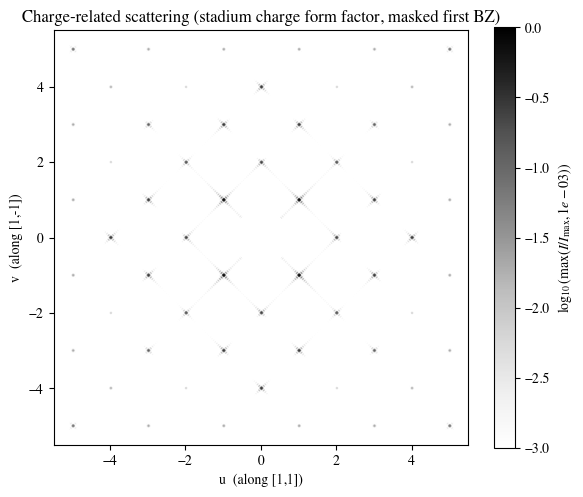

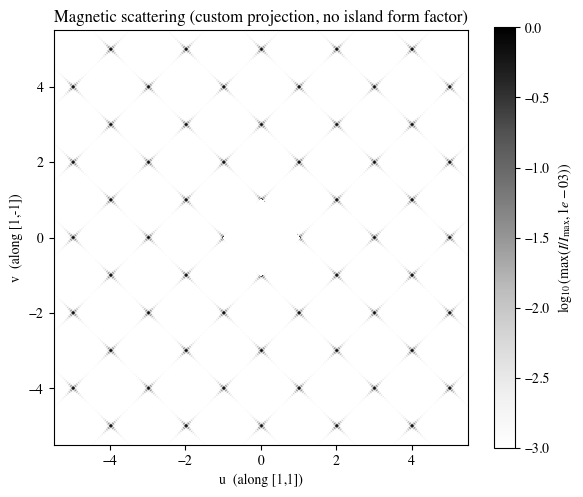

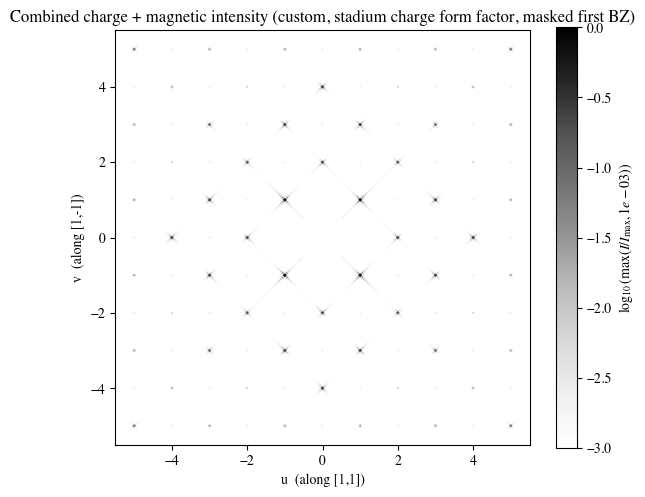

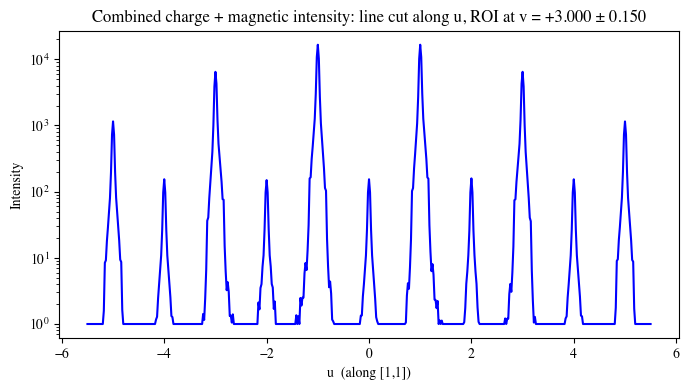


Line cut ROI: v = +3.000 ± 0.150 using 15 rows from +2.860 to +3.140


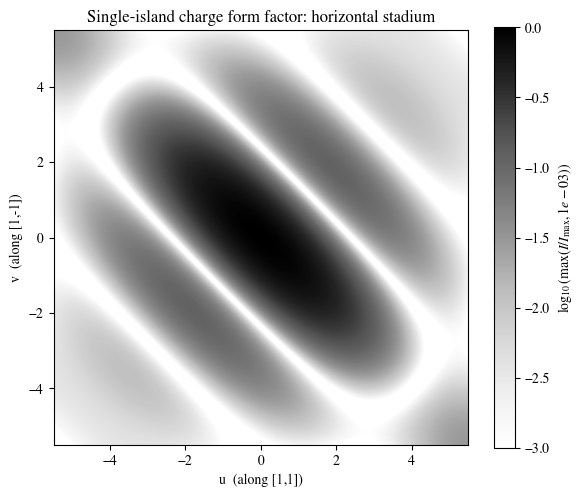

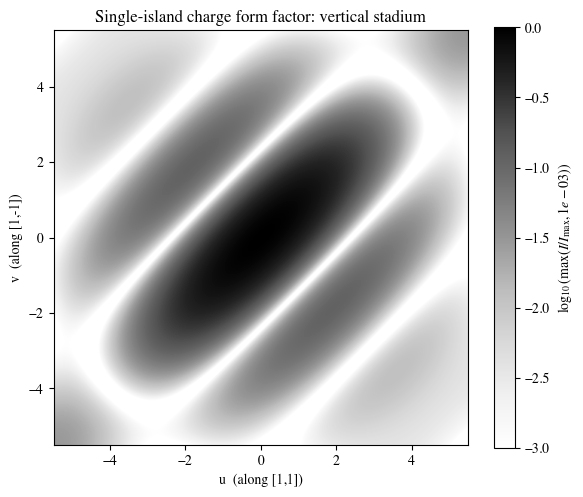

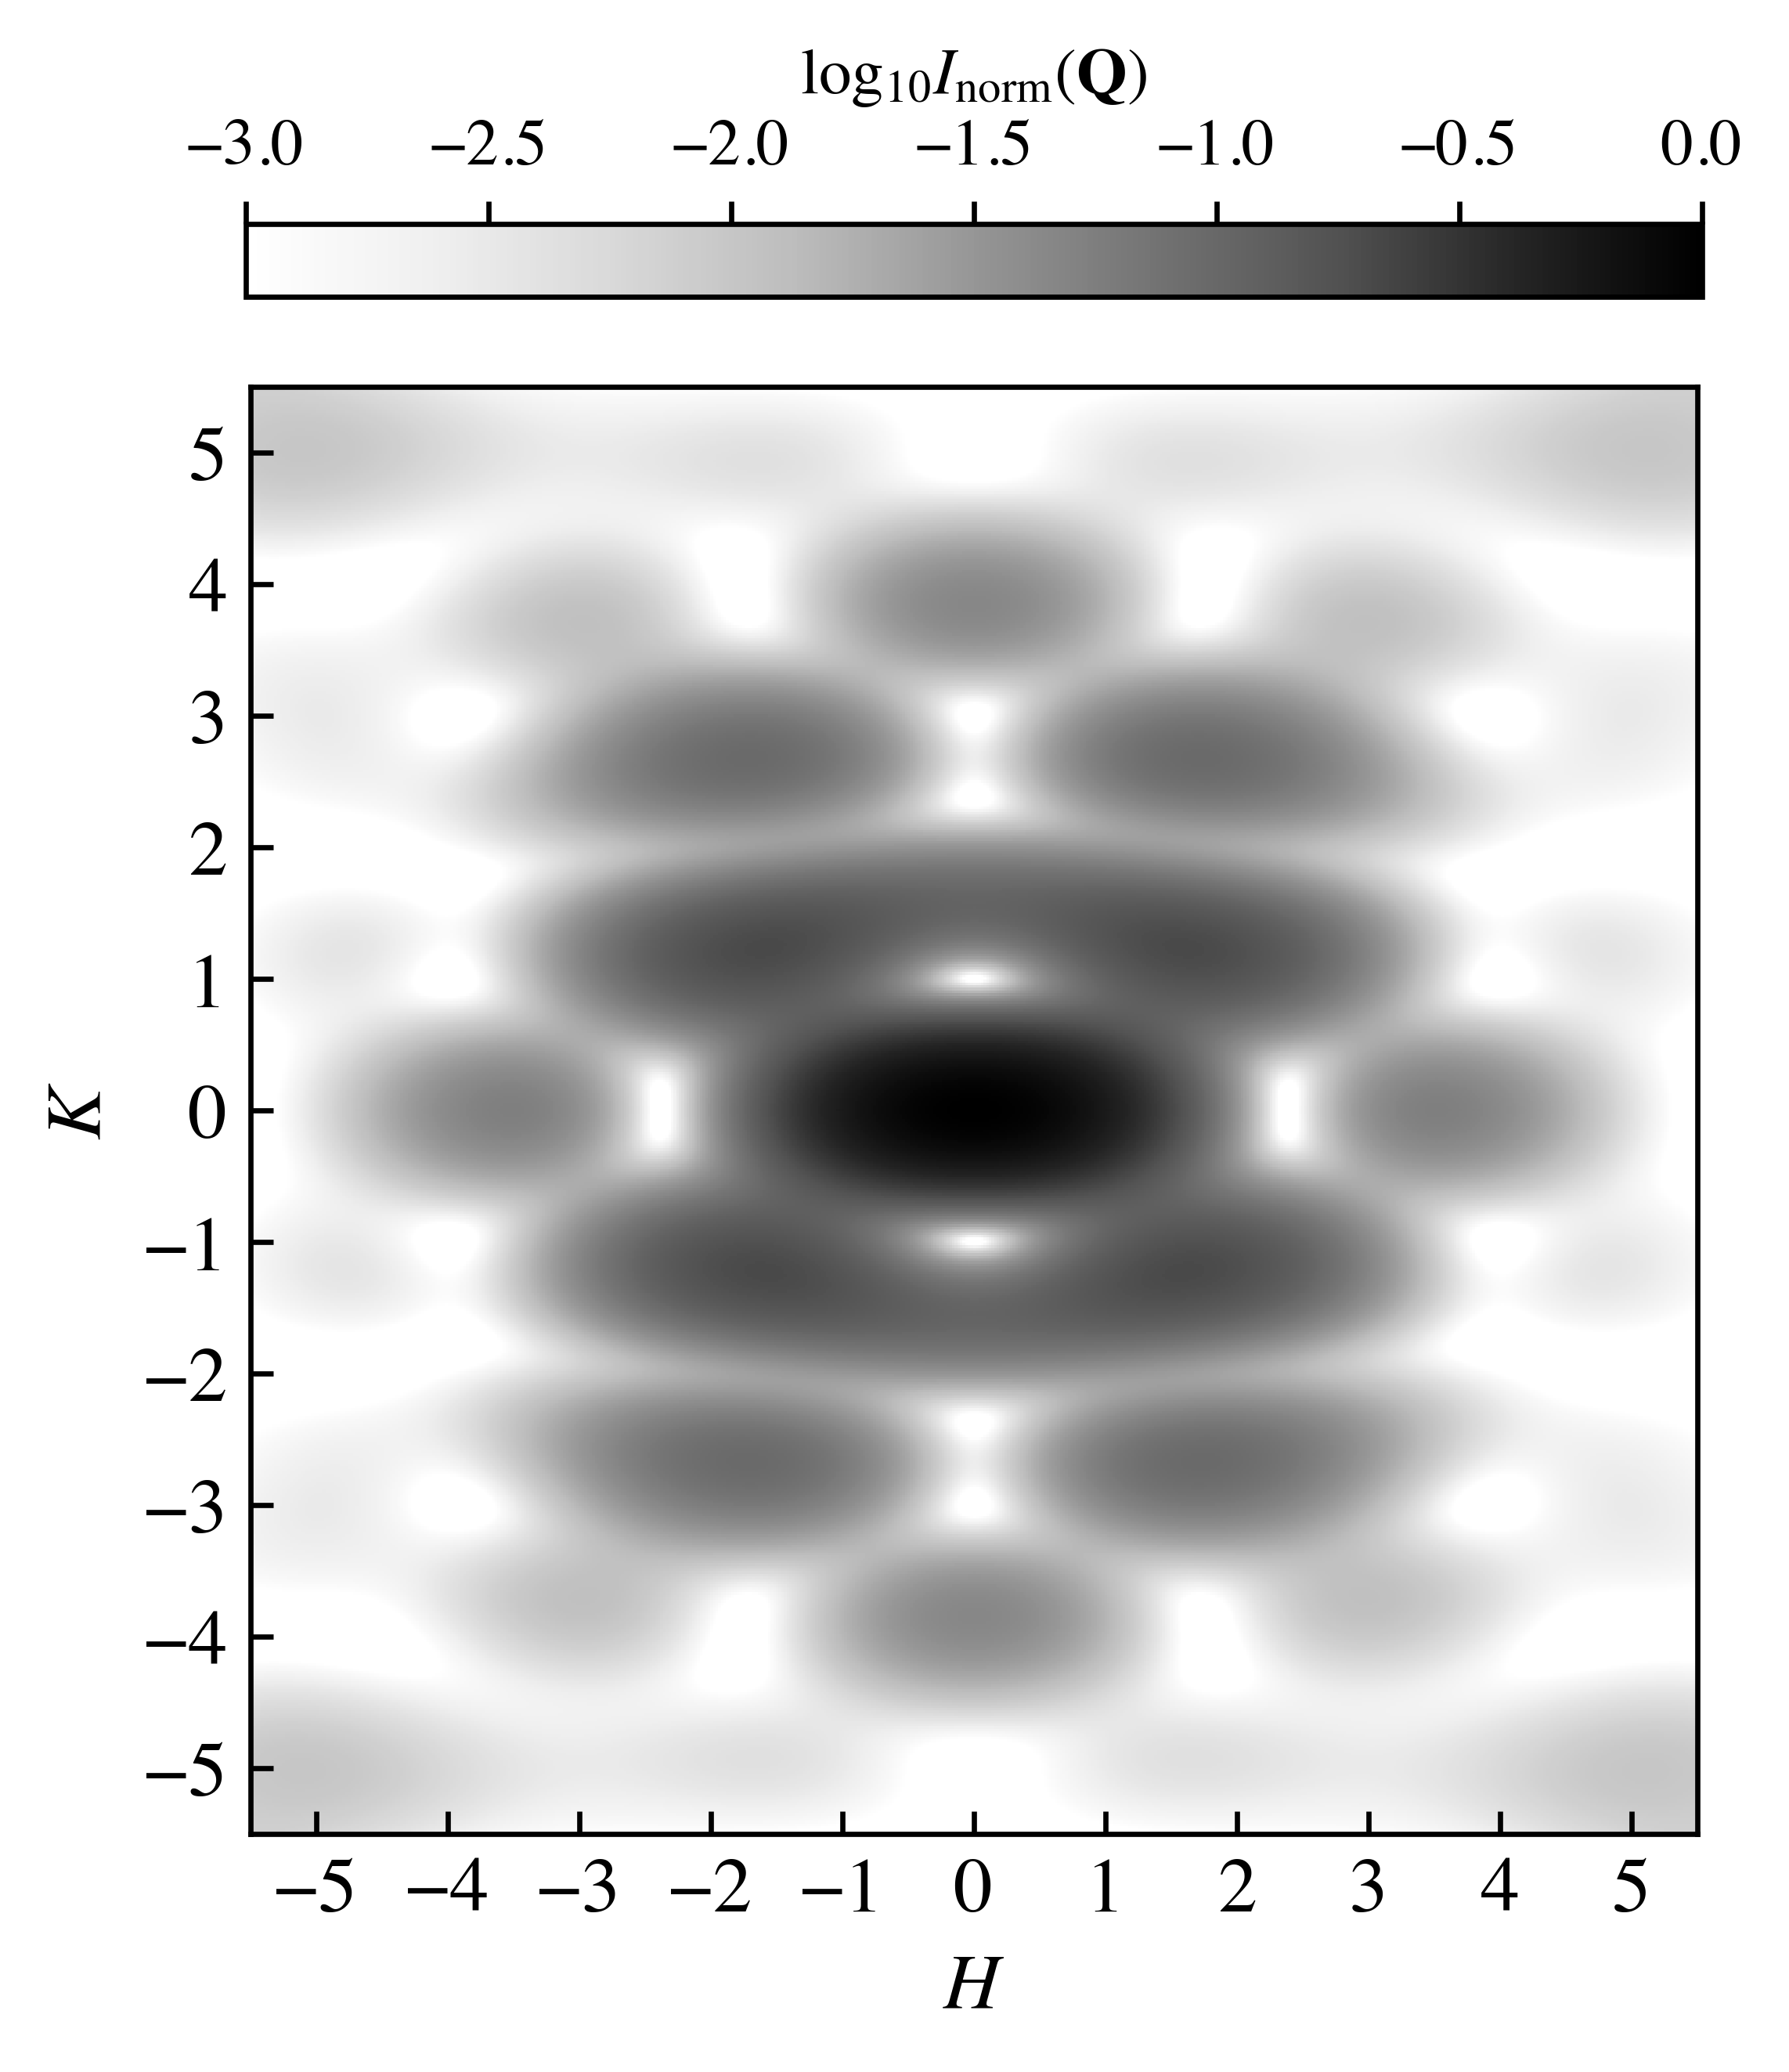

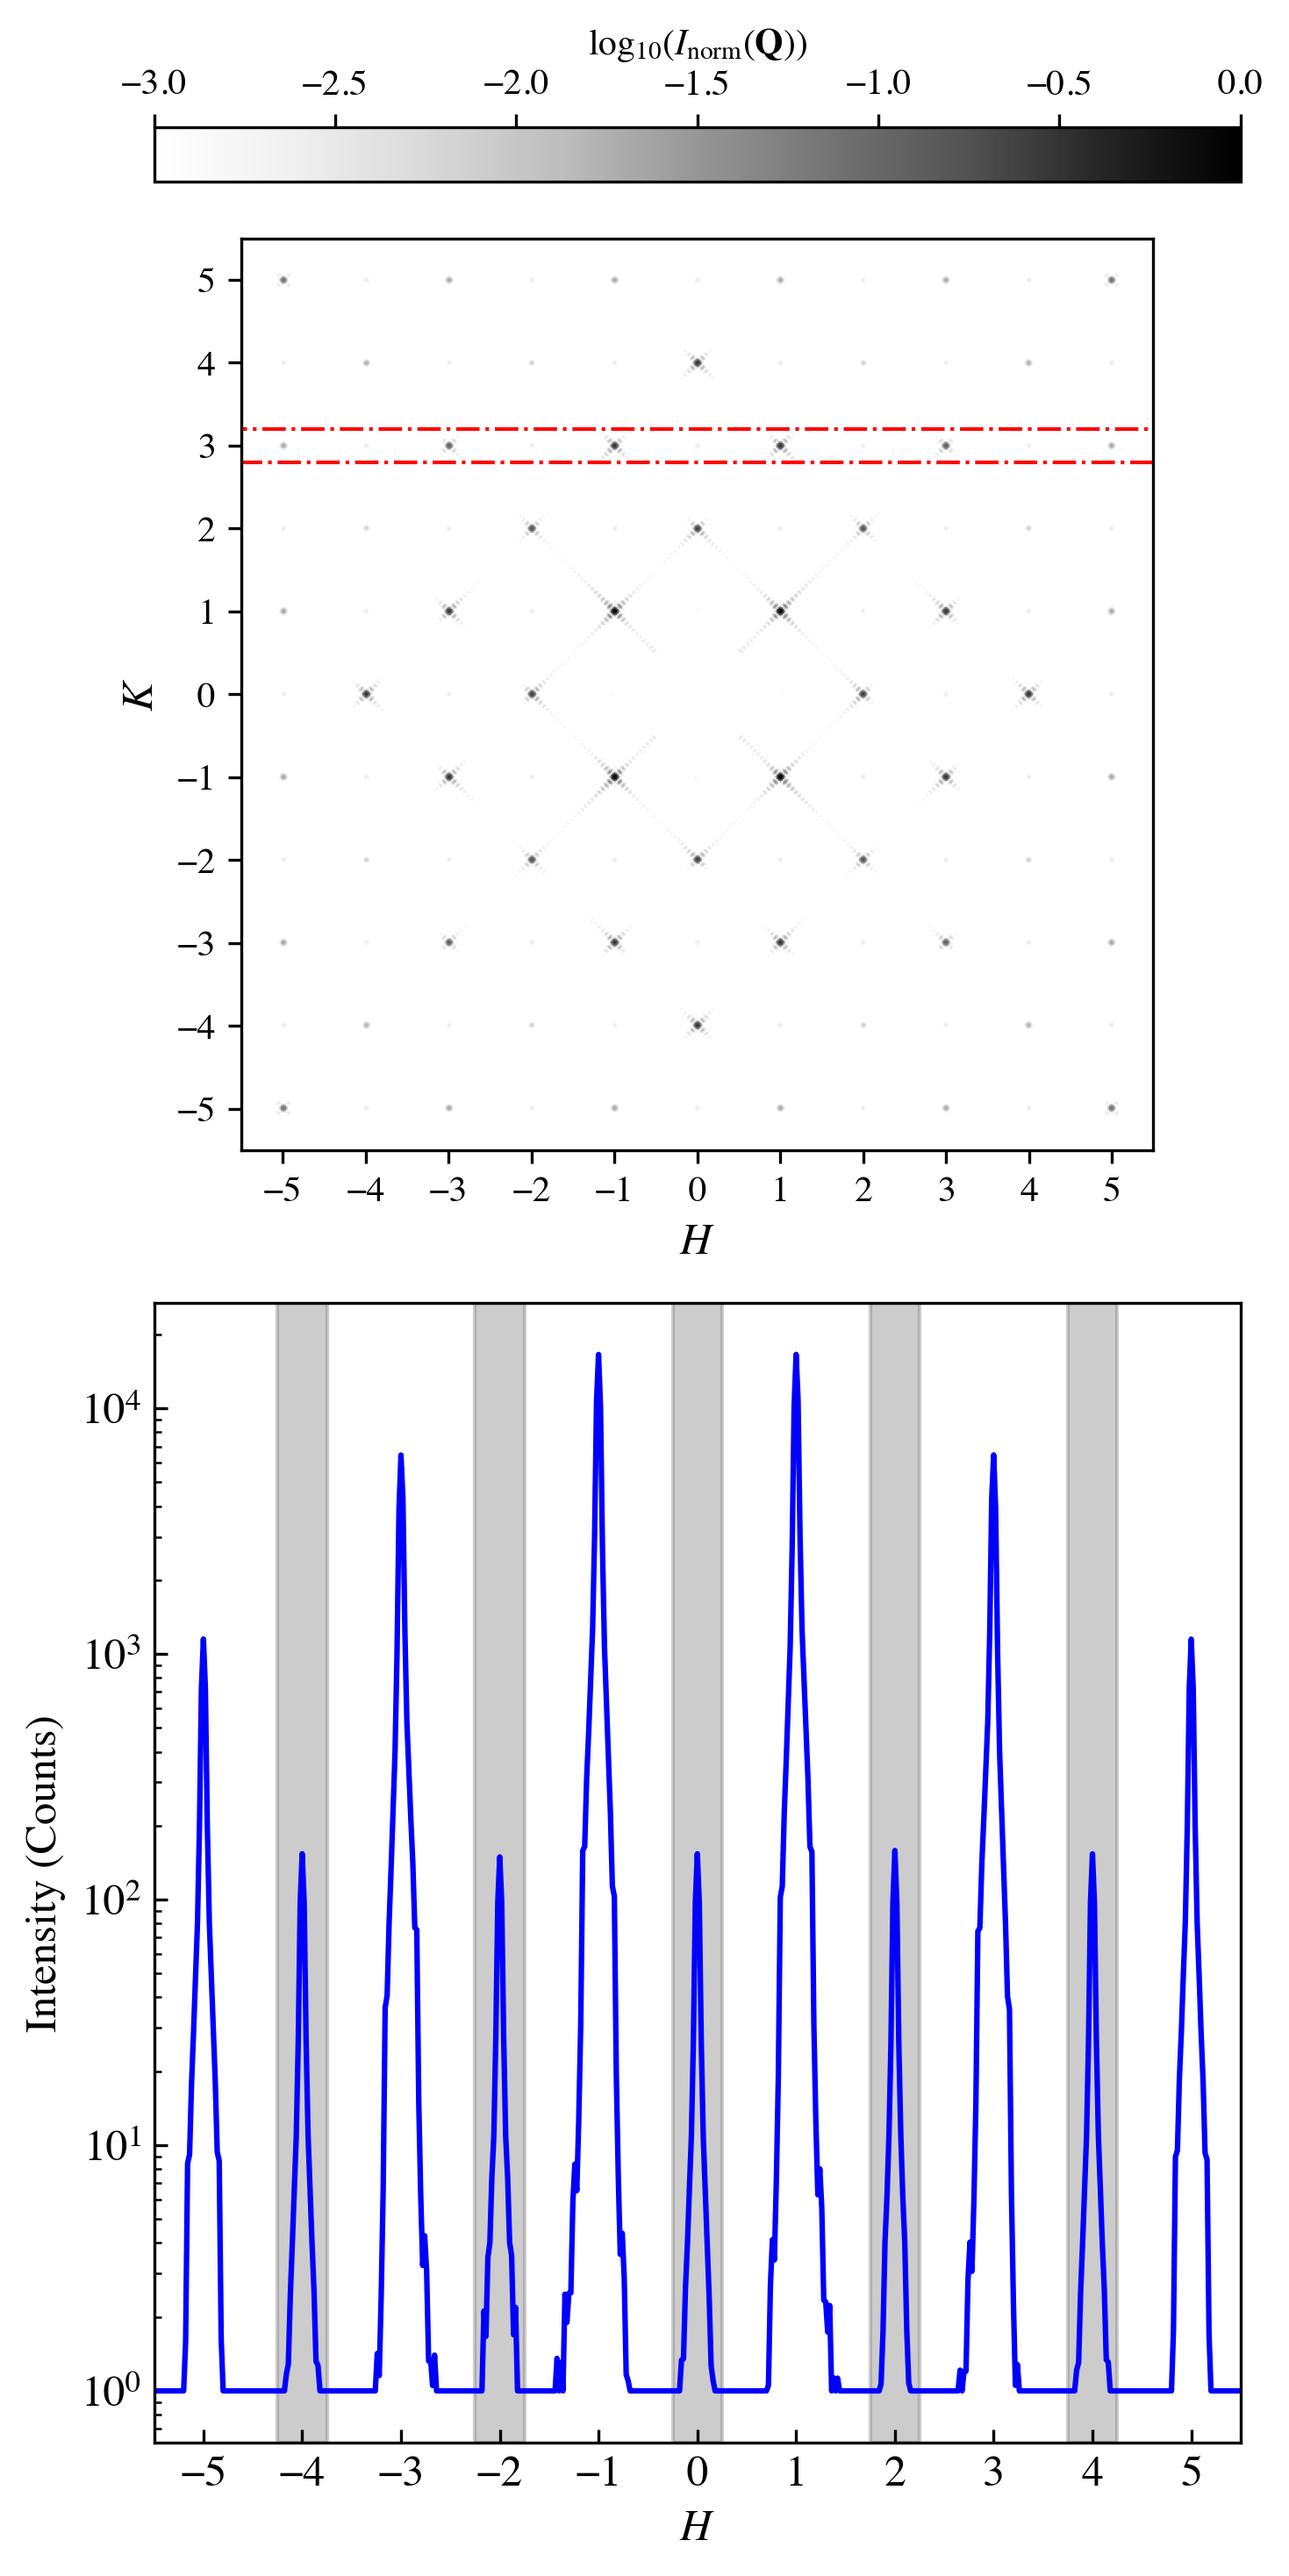

In [3]:
# ======================================================================
# Main
# ======================================================================

def main():
    # --------------------------------------------------------------
    # User controls
    # --------------------------------------------------------------
    a = 1.0
    n1 = 24
    n2 = 24
    m0 = 1.0

    # manuscript geometry: beam along [1,1]
    lattice_rotation_deg = 45.0

    # reciprocal-space range in diagonal indexing
    uv_max = 5.5
    nk = 551

    chunk_size = 128
    plot_floor = 1e-3

    # magnetic projection
    projection_mode = "custom"      # "beam", "q", or "custom"
    beam_direction_lab = (1.0, 0.0)
    custom_direction_lab = (1.0, 1.0)

    # charge form factor: stadium islands
    use_stadium_charge_form_factor = True
    island_length = 0.85          # units of lattice constant a
    island_width = 0.27           # units of lattice constant a

    # coherent mixing
    alpha_charge = 1.0 + 0.0j
    alpha_mag = 0.05 + 0.0j

    # masking
    mask_first_bz = True
    first_bz_margin = 0.0
    beamstop_radius_q = None      # example: 0.75 * 2.0 * np.pi / a

    # diagnostics
    plot_single_island_charge_form_factors = True
    plot_basis_charge_form_factor_only = True

    # new: line cut for combined map
    plot_combined_u_linecut = True
    v_roi_center = 3.0
    v_roi_halfwidth = 0.15
    linecut_logy = True
    linecut_floor = 1e-0

    # --------------------------------------------------------------
    # Build rotated lattice
    # --------------------------------------------------------------
    lattice_lab, positions, charge_weights, moments, lattice_island = make_square_asi_typeI_supercell(
        a=a,
        n1=n1,
        n2=n2,
        m0=m0,
        lattice_rotation_deg=lattice_rotation_deg,
    )

    # --------------------------------------------------------------
    # Reciprocal-space grid in diagonal indexing (u,v)
    # --------------------------------------------------------------
    u = np.linspace(-uv_max, uv_max, nk)
    v = np.linspace(-uv_max, uv_max, nk)
    uu, vv = np.meshgrid(u, v, indexing="xy")

    hx, hy = diag_to_island_indices(uu, vv)

    b1_lab, b2_lab = reciprocal_basis_2d(lattice_lab.a1, lattice_lab.a2)
    qx, qy = hk_to_q(hx, hy, b1_lab, b2_lab)

    # --------------------------------------------------------------
    # Charge form-factor handle
    # --------------------------------------------------------------
    if use_stadium_charge_form_factor:
        def charge_ff(qx_in, qy_in, site):
            return stadium_charge_form_factor(
                qx_in, qy_in, site,
                island_length=island_length,
                island_width=island_width,
            )
    else:
        charge_ff = None

    # --------------------------------------------------------------
    # Compute maps
    # --------------------------------------------------------------
    maps = compute_maps(
        qx, qy,
        positions, charge_weights, moments,
        basis_sites=lattice_lab.basis,
        charge_form_factor_fn=charge_ff,
        chunk_size=chunk_size,
        projection_mode=projection_mode,
        beam_direction_lab=beam_direction_lab,
        custom_direction_lab=custom_direction_lab,
    )

    I_combined = combine_charge_and_magnetic(
        maps["A_charge"],
        maps["A_mag"],
        alpha_charge=alpha_charge,
        alpha_mag=alpha_mag,
    )

    # --------------------------------------------------------------
    # Build display mask
    # --------------------------------------------------------------
    mask = np.zeros_like(uu, dtype=bool)

    if mask_first_bz:
        mask |= first_bz_mask_square_island_from_uv(uu, vv, margin=first_bz_margin)

    if beamstop_radius_q is not None:
        mask |= circular_beamstop_mask_q(qx, qy, radius=beamstop_radius_q)

    ff_label = "stadium charge form factor" if use_stadium_charge_form_factor else "no charge form factor"
    mask_label = "masked first BZ" if mask_first_bz else "no BZ mask"

    # --------------------------------------------------------------
    # Main reciprocal-space plots
    # --------------------------------------------------------------
    plot_map(
        uu, vv, maps["I_charge"],
        title=f"Charge-related scattering ({ff_label}, {mask_label})",
        xlabel="u  (along [1,1])",
        ylabel="v  (along [1,-1])",
        plot_floor=plot_floor,
        mask=mask,
    )

    plot_map(
        uu, vv, maps["I_mag"],
        title=f"Magnetic scattering ({projection_mode} projection, no island form factor)",
        xlabel="u  (along [1,1])",
        ylabel="v  (along [1,-1])",
        plot_floor=plot_floor,
        mask=mask,
    )

    plot_map(
        uu, vv, I_combined,
        title=f"Combined charge + magnetic intensity ({projection_mode}, {ff_label}, {mask_label})",
        xlabel="u  (along [1,1])",
        ylabel="v  (along [1,-1])",
        plot_floor=plot_floor,
        mask=mask,
    )

    # --------------------------------------------------------------
    # New: line cut along u for ROI around v = +3
    # --------------------------------------------------------------
    if plot_combined_u_linecut:
        u_line, I_line, row_selector = extract_u_linecut_roi(
            u_axis=u,
            v_axis=v,
            I=I_combined,
            v_center=v_roi_center,
            v_halfwidth=v_roi_halfwidth,
            mask=mask,
        )

        plot_linecut_u(
            u_line,
            I_line,
            v_center=v_roi_center,
            v_halfwidth=v_roi_halfwidth,
            title_prefix="Combined charge + magnetic intensity",
            logy=linecut_logy,
            line_floor=linecut_floor,
        )

        v_used = v[row_selector]
        print(
            f"\nLine cut ROI: v = {v_roi_center:+.3f} ± {v_roi_halfwidth:.3f} "
            f"using {len(v_used)} rows from {v_used.min():+.3f} to {v_used.max():+.3f}"
        )

    # --------------------------------------------------------------
    # Charge form-factor diagnostic plots
    # --------------------------------------------------------------
    if charge_ff is not None and plot_single_island_charge_form_factors:
        ff_h = compute_single_site_charge_form_factor_map(
            qx, qy,
            lattice_lab.basis[0],
            charge_ff,
        )
        ff_v = compute_single_site_charge_form_factor_map(
            qx, qy,
            lattice_lab.basis[1],
            charge_ff,
        )

        plot_map(
            uu, vv, ff_h["I_ff_charge"],
            title="Single-island charge form factor: horizontal stadium",
            xlabel="u  (along [1,1])",
            ylabel="v  (along [1,-1])",
            plot_floor=plot_floor,
            mask=None,
        )

        plot_map(
            uu, vv, ff_v["I_ff_charge"],
            title="Single-island charge form factor: vertical stadium",
            xlabel="u  (along [1,1])",
            ylabel="v  (along [1,-1])",
            plot_floor=plot_floor,
            mask=None,
        )

    if charge_ff is not None and plot_basis_charge_form_factor_only:
        basis_ff = compute_basis_charge_form_factor_only_map(
            qx, qy,
            lattice_lab.basis,
            charge_ff,
        )

        fig3, ax3 = plt.subplots(figsize=[5, 5], dpi=600) 
        im = plot_map(
            uu, vv, basis_ff["I_basis_ff_charge"],
            title="",
            xlabel="u  (along [1,1])",
            ylabel="v  (along [1,-1])",
            plot_floor=plot_floor,
            mask=None,
            ax=ax3,
            show_colorbar=False
        )

        ax3.set_xlim(-5.5, 5.5)
        ax3.set_ylim(-5.5, 5.5)

        # Labels and ticks
        ax3.set_xlabel(r'$H$', fontsize=12)
        ax3.set_ylabel(r'$K$', fontsize=12)
        ax3.tick_params(axis='both', which='both', direction='in', labelsize=12)
        ax3.set_aspect('equal')

        # Major ticks
        ax3.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
        ax3.set_yticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

        # Horizontal colorbar on top
        cbar = fig3.colorbar(im, ax=ax3, location='top', shrink=0.8, pad=0.05, format='{x:1.1f}')
        cbar.set_label(r'$\mathrm{log}_{10}I_{\mathrm{norm}}(\mathbf{Q})$')

        plt.savefig('Figure6.png', dpi = 600)

    # --------------------------------------------------------------
    # Plot manuscript figure
    # --------------------------------------------------------------
    make_manuscript_figure = True

    if make_manuscript_figure:
        plt.rcParams["font.family"] = "times"
        plt.rcParams["mathtext.fontset"] = "stix"

        fig, ax = plt.subplots(2, 1, figsize=(5, 10), dpi=300)

        # ROI boundaries
        x_min, x_max = -6.0, 6.0
        y_min, y_max = 2.8, 3.2

        # ROI rectangle
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         linewidth=1, edgecolor='red', facecolor='none', linestyle='-.')

        # Top panel: reciprocal-space map
        im0 = plot_map(
            uu, vv, I_combined,
            title="",
            xlabel=r'$H$',
            ylabel=r'$K$',
            plot_floor=plot_floor,
            mask=mask,
            ax=ax[0],
            show_colorbar=False,
        )

        ax[0].set_aspect('equal')
        ax[0].add_patch(rect)

        # Major ticks
        ax[0].set_xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
        ax[0].set_yticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

        cbar = plt.colorbar(im0, ax=ax[0], location='top', shrink=1, pad=0.05)
        cbar.set_label(r'log$_{10}(I_{\mathrm{norm}}(\mathbf{Q}))$')
        ax[0].set_xlabel(r'$H$', fontsize=12)
        ax[0].set_ylabel(r'$K$', fontsize=12)

        # ROI rectangle
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1.0,
            edgecolor="red",
            facecolor="none",
            linestyle="-."
        )
        
        # Bottom panel: ROI line cut
        plot_linecut_u(
            u_line,
            I_line,
            v_center=v_roi_center,
            v_halfwidth=v_roi_halfwidth,
            title_prefix="",
            logy=linecut_logy,
            line_floor=linecut_floor,
            ax=ax[1],
        )

        ax[1].set_xlim(-5.5, 5.5)
        ax[1].set_xlabel(r'$H$', fontsize=12)
        ax[1].set_ylabel('Intensity (Counts)', fontsize=12)
        ax[1].set_xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
        ax[1].tick_params(axis='both', which='both', direction='in', labelsize=12)
        ax[1].set_title("")

        # Shade area around peaks located at H = -4, -2, 2, 4
        peak_positions = [-4, -2, 0, 2, 4]
        for peak in peak_positions:
            ax[1].axvspan(peak - 0.25, peak + 0.25, color='gray', alpha=0.4)

        plt.tight_layout()

        plt.savefig('Figure7.png', dpi = 600)
    
if __name__ == "__main__":
    main()